# Viscosity Pipeline Usage Example

This notebook shows how to run the reusable viscosity pipeline on:
`dynamic_analysis_L60kcP_siltech_A37kcP_custom_20260511_085338.csv`

Workflow covered:
1. Load dataset
2. Normalize x-axis by cell
3. Trim before-hit and after-contact zones
4. Fit Polynomial(2nd) and Hyperbola
5. Map known real viscosities (user input)
6. Extrapolate unknown viscosities
7. Plot fits and accuracy

In [1]:
from pathlib import Path
import sys

import pandas as pd

# Locate helper module robustly across common notebook working directories.
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / 'results' / 'Auto-runs',
    Path.cwd().parent,
]
helper_dir = next((d for d in candidate_dirs if (d / 'viscosity_pipeline_helper.py').exists()), None)
if helper_dir is None:
    raise FileNotFoundError('Could not locate viscosity_pipeline_helper.py')
if str(helper_dir) not in sys.path:
    sys.path.insert(0, str(helper_dir))

from viscosity_pipeline_helper import run_viscosity_pipeline

In [2]:
# Dataset to analyze
csv_path = 'dynamic_analysis_L60kcP_siltech_A37kcP_custom_20260511_085338.csv'

# USER INPUT: known calibration viscosities in cP.
# Keep only cells you trust for calibration. Unknown cells can be omitted.
real_viscosity_map = {
    1: 1000,
    2: 1154,
    3: 3347,
    4: 6611,
    5: 5865,
    6: 8930,
    7: 11860,
    8: 14590,
    9: 19000,
    10: 22730,
    11: 31870,
    12: 40850,
    13: 48520,
}

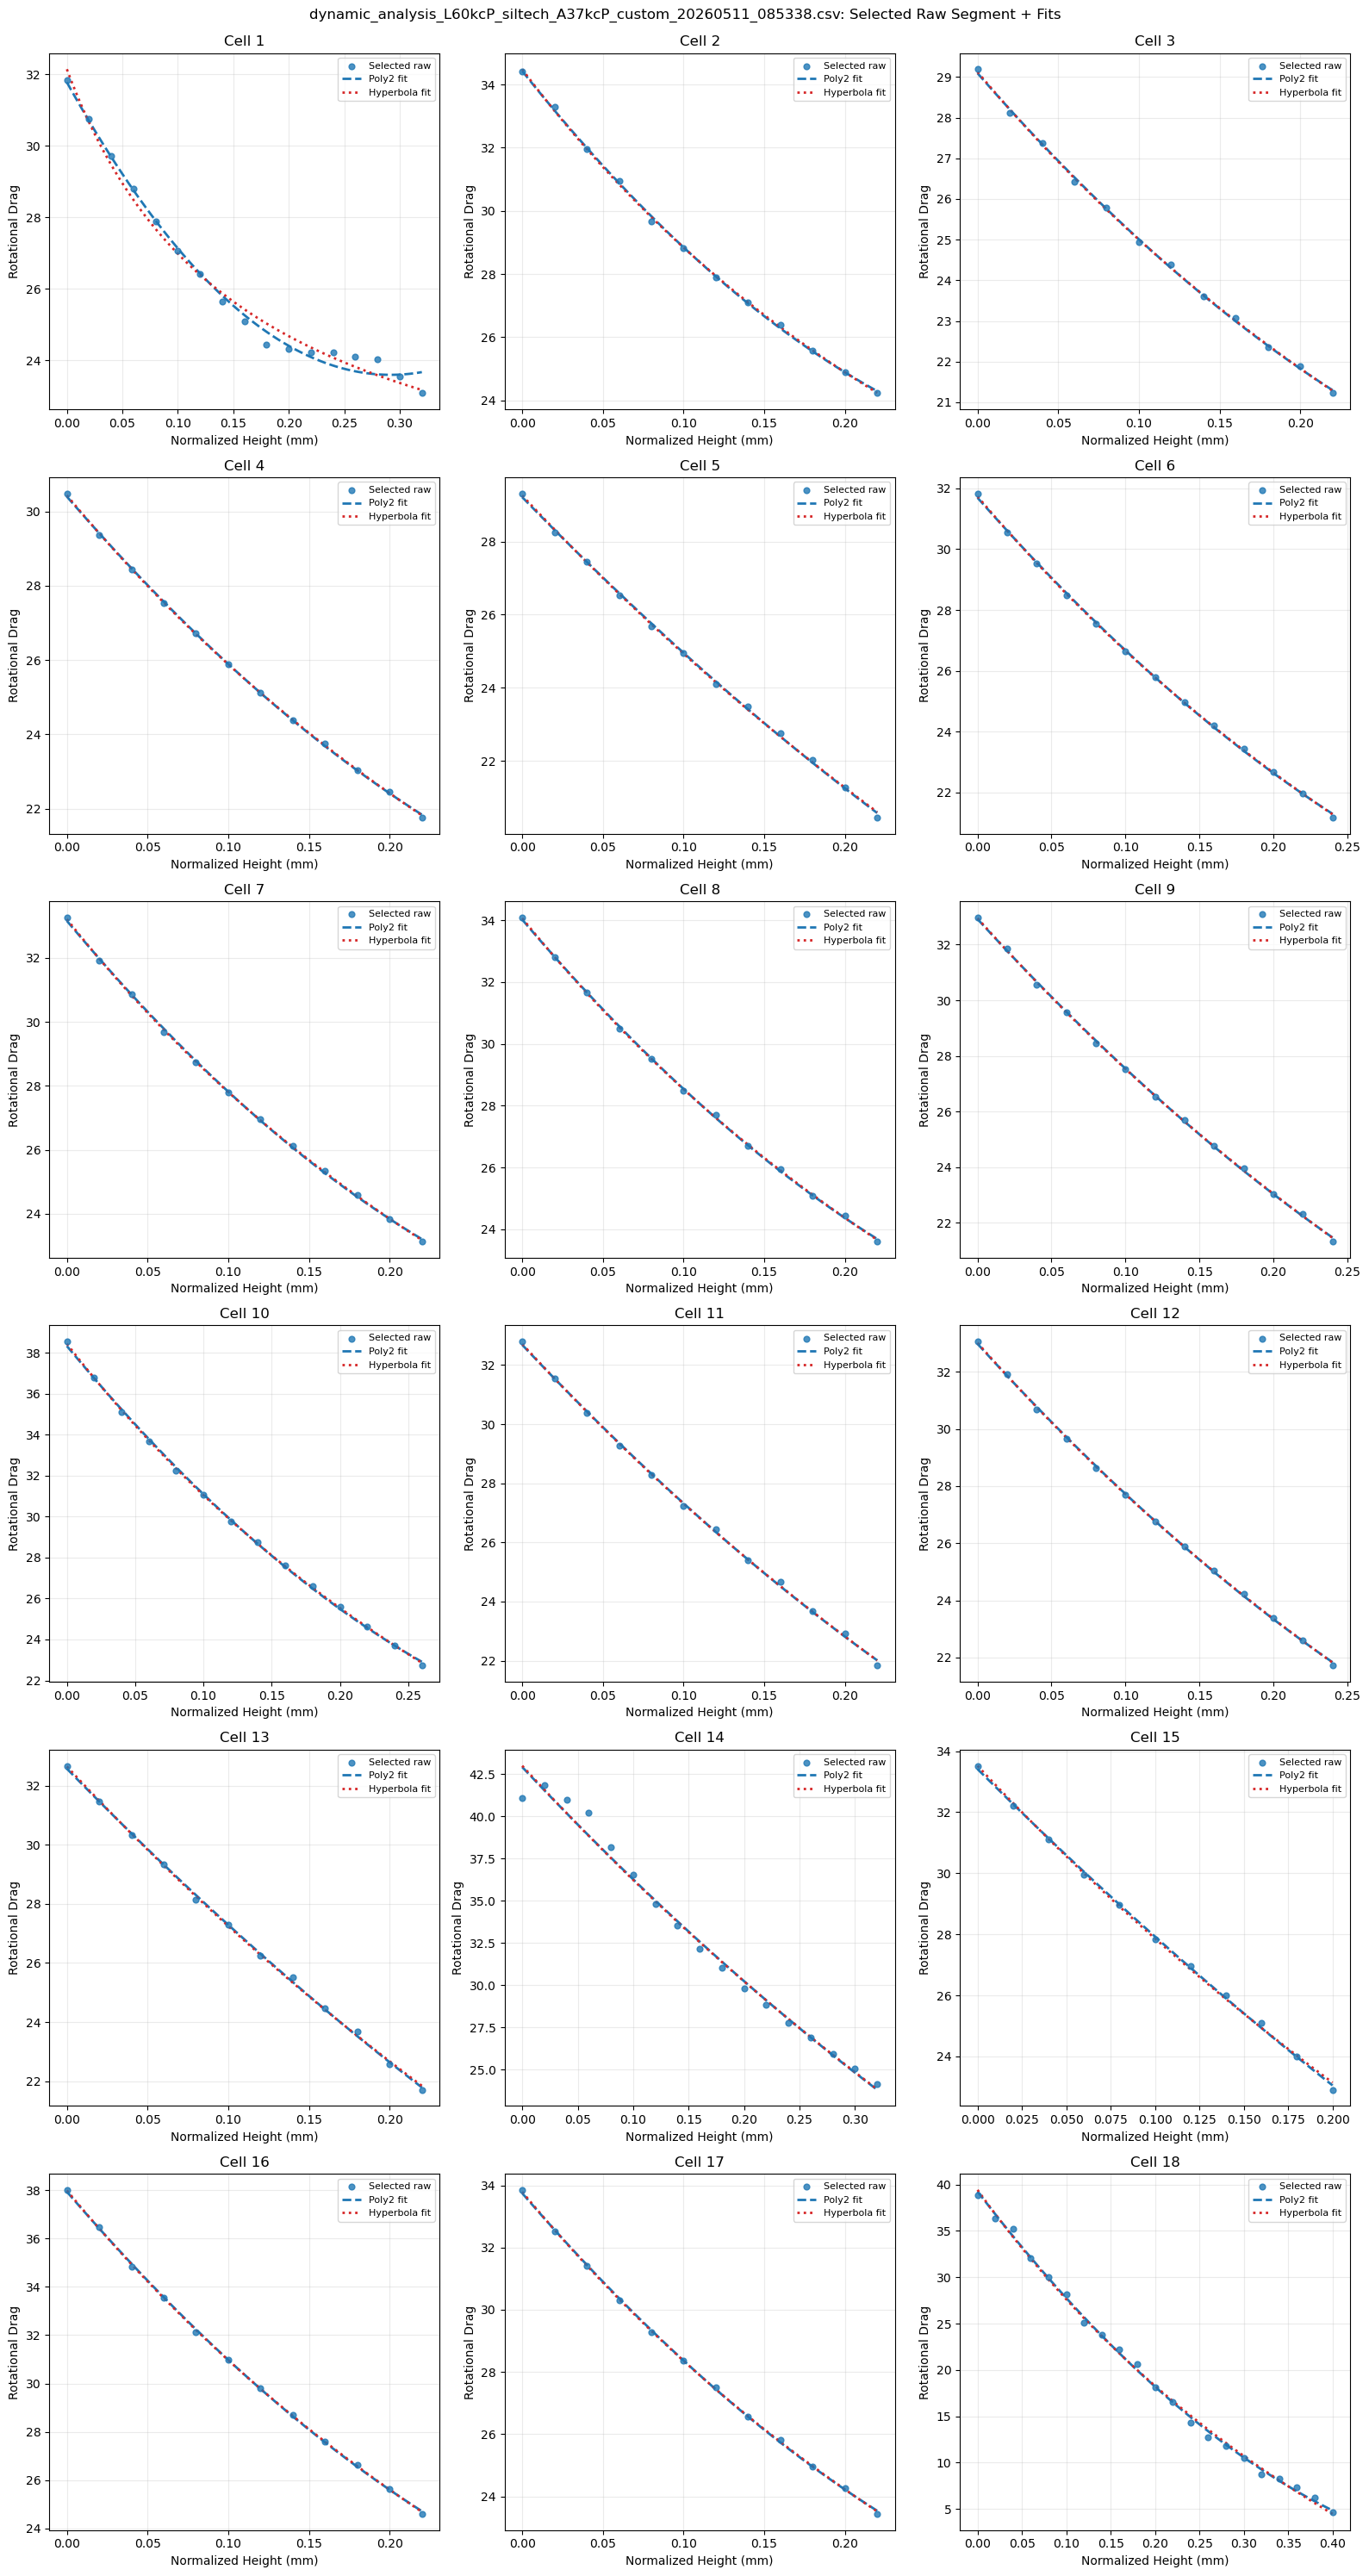

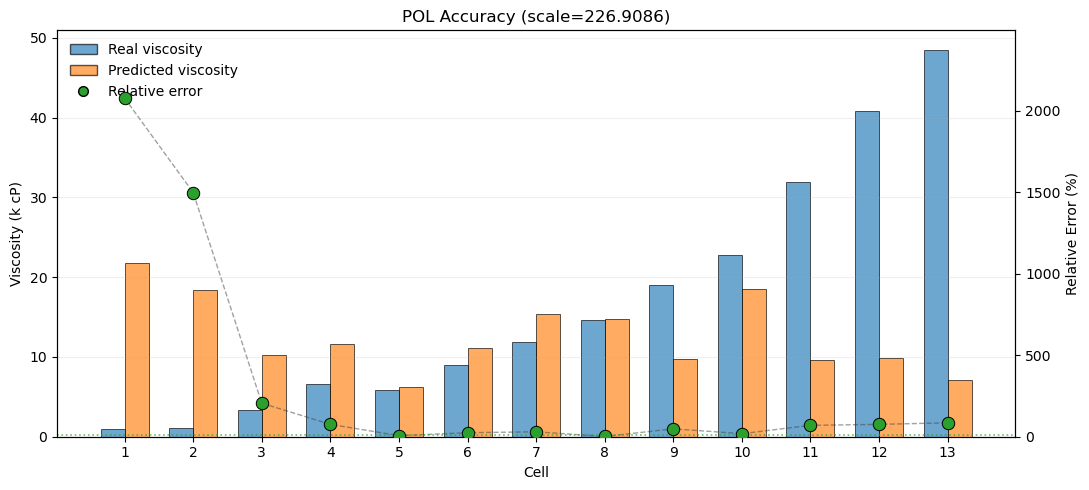

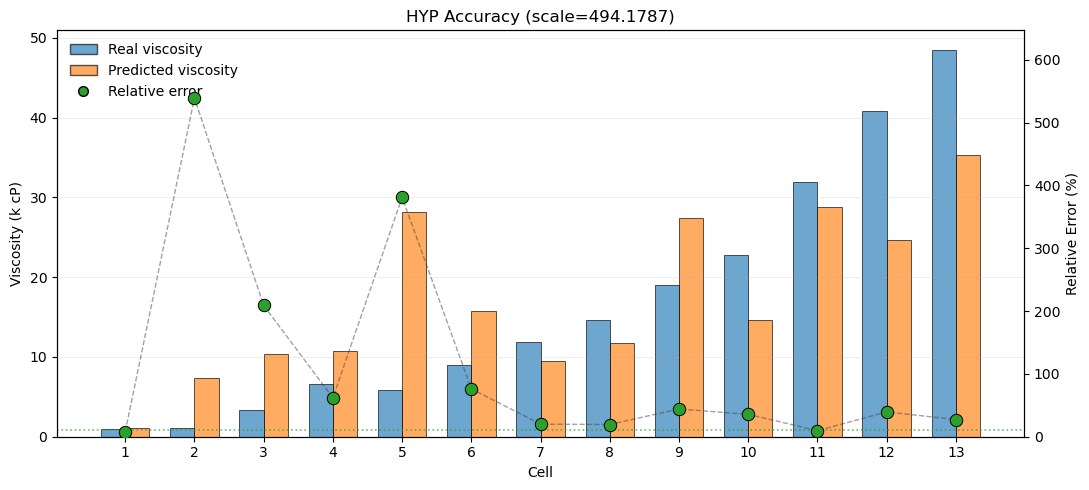

Learned scaling factors: {'poly': 226.90858723269017, 'hyperbola': 494.1786878044089}


In [3]:
pipeline_out = run_viscosity_pipeline(
    csv_path=csv_path,
    real_viscosity_map=real_viscosity_map,
    visualize=True,
)

print('Learned scaling factors:', pipeline_out['scales'])

In [4]:
pred_cols = [
    'cell',
    'a_poly2',
    'a_hyperbola',
    'real_viscosity',
    'predicted_visc_pol',
    'predicted_visc_hyp',
    'rel_error_pol',
    'rel_error_hyp',
    'is_calibration',
]

pred_df = pipeline_out['predictions'][pred_cols].sort_values('cell').reset_index(drop=True)
display(pred_df)

# Optional: save the predictions table
# pred_df.to_csv('viscosity_predictions_dynamic_analysis_L60kcP.csv', index=False)

,cell,a_poly2,a_hyperbola,real_viscosity,predicted_visc_pol,predicted_visc_hyp,rel_error_pol,rel_error_hyp,is_calibration
0,1,95.977704,2.185686,1000.0,21778.165179,1080.119463,2077.816518,8.011946,True
1,2,81.284083,14.923180,1154.0,18444.056391,7374.717289,1498.271784,539.056957,True
2,3,45.099157,20.923696,3347.0,10233.386021,10340.044838,205.748014,208.934713,True
3,4,51.251600,21.664288,6611.0,11629.428212,10706.029564,75.910274,61.942665,True
4,5,27.534948,57.086490,5865.0,6247.916190,28210.926498,6.528835,381.004714,True
5,6,49.056737,31.833290,8930.0,11131.394890,15731.333375,24.651678,76.162748,True
6,7,68.076127,19.199982,11860.0,15447.057801,9488.222002,30.245007,19.998128,True
7,8,65.228043,23.780617,14590.0,14800.803132,11751.874018,1.444847,19.452543,True
8,9,43.177967,55.435845,19000.0,9797.451499,27395.213203,48.434466,44.185333,True
9,10,81.440208,29.618193,22730.0,18479.482487,14636.679663,18.700033,35.606337,True
